# <b><font color='lightcoral'>Градиентный бустинг</font></b>

In [105]:
# Импорт библиотек
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [106]:
# 1. Подготовка данных
X = np.array([[0], [1], [2], [3], [4], [5]])   # признак: бюджет (тыс. у.е.), форматируем как колонку
y = np.array([4, 6, 8, 12, 18, 24])           # целевая переменная: продажи (тыс. единиц)

In [107]:
# Разделите данные на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [108]:
# 2. Создание и настройка модели градиентного бустинга
model = GradientBoostingRegressor(
    n_estimators = 5,    # число деревьев в ансамбле (итераций бустинга)
    max_depth = 1,       # максимальная глубина деревьев (1 = решающий пень)
    random_state = 42     # фиксируем случайность для воспроизводимости
)

In [109]:
# 3. Обучение модели на данных
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",5
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`

In [110]:
# 4. Получение прогнозов модели
y_pred = model.predict(X_test)

In [111]:
print("Прогнозы модели:", y_pred)
print("Фактические значения:", y_test)

Прогнозы модели: [13.398265 13.398265]
Фактические значения: [4 6]


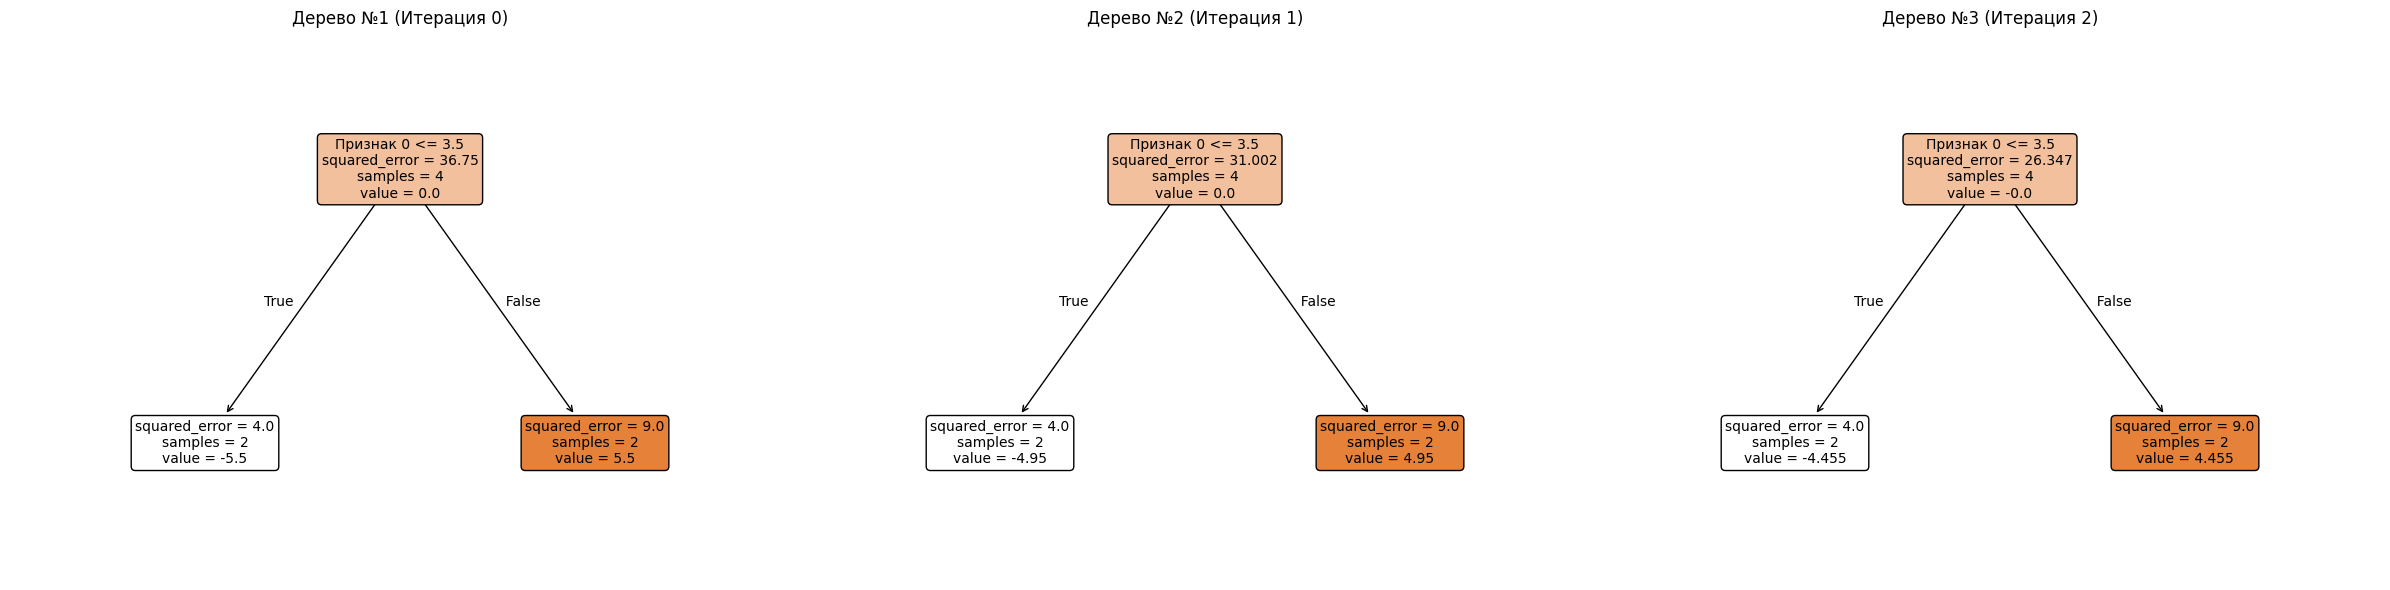

In [112]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 6))
for i in range(3):
    # Извлекаем i-е дерево из ансамбля
    tree_to_plot = model.estimators_[i, 0]
    
    # Рисуем дерево в соответствующем подграфике axes[i]
    plot_tree(tree_to_plot, 
              feature_names=[f'Признак {j}' for j in range(X.shape[1])],
              filled=True, 
              rounded=True,
              fontsize=10,
              ax=axes[i])
    
    axes[i].set_title(f"Дерево №{i+1} (Итерация {i})")

# Корректируем расположение, чтобы тексты не накладывались
plt.tight_layout()
plt.show()

In [131]:
from sklearn.datasets import fetch_california_housing

In [132]:
df_california = fetch_california_housing()
df_california


{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [133]:
# В переменную X запишите все данные из компонента data датасета
X = df_california.data # Характеристики

In [ ]:
y = df_california.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [117]:
model_lin_reg = GradientBoostingRegressor(
    n_estimators=10,  # число деревьев в ансамбле
    max_depth=3,       # максимальная глубина деревьев
    random_state=42    # фиксируем случайность для воспроизводимости
)

In [118]:
model_lin_reg.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)

In [119]:
y_pred = model_lin_reg.predict(X_test)

In [ ]:
# Считаем метрики оценки линейной регрессии для цифровых данных
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")  
print(f"R-squared: {r2}")

MSE на тестовом наборе для градиентного бустинга: 0.653305504099632
R² на тестовом наборе для градиентного бустинга: 0.5014491544642552


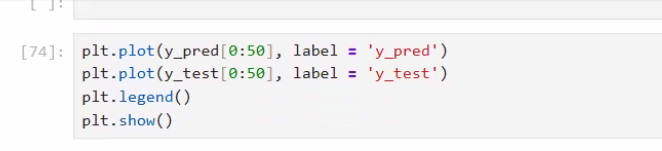

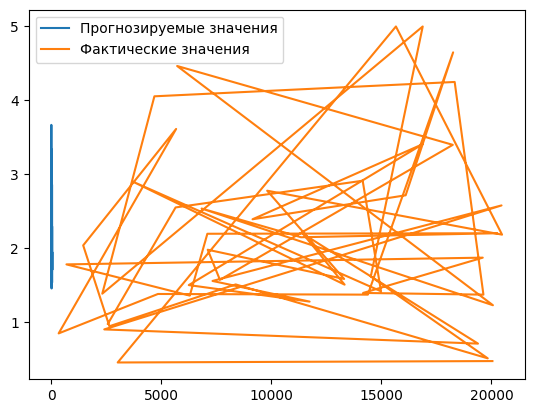

In [121]:
# надо посотртиь график в две линии на котором будет видно как меняются предсказания модели и фактические значения в зависимости от признака.
# надо ограничить чтоб было только две линии предсказания модели и фактические значения
plt.plot(y_pred[0:50], label='Прогнозируемые значения')
plt.plot(y_test[0:50], label='Фактические значения')
plt.legend()
plt.show()


In [ ]:
# from sklearn.metrics import mean_squared_error

# mean_squared_error_ = 100
# best_i = 1
# best_j = 1

# for i in range(1, 50):
#     for j in range(1, 50):
#         model = GradientBoostingRegressor(
#             n_estimators=i,    # число деревьев в ансамбле (итераций бустинга)
#             max_depth=j,       # максимальная глубина деревьев (1 = решающий пень)
#             random_state=42    # фиксируем случайность для воспроизводимости
#         )
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)
#         mse = mean_squared_error(y_test, y_pred)
#         print(f"Mean Squared Error: {mse}")

#         if mse <= mean_squared_error_:
#             mean_squared_error_ = mse
#             best_i = i
#             best_j = j

# print("Лучший MSE:", mean_squared_error_)
# print("Лучшие параметры:", best_i, best_j)

In [129]:
import time
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

start = time.time()

# Ускоряем тюнинг: берем часть train
X_small, _, y_small, _ = train_test_split(
    X_train, y_train, train_size=5000, random_state=42
)

param_dist = {
    "n_estimators": list(range(1, 51)),
    "max_depth": list(range(1, 51))
}

search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=35,                  # 35 случайных комбинаций вместо 2401
    scoring="neg_mean_squared_error",
    cv=2,                       # быстрее, чем 3-5
    n_jobs=-1,                  # все ядра
    random_state=42,
    verbose=1
)

search.fit(X_small, y_small)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("Лучшие параметры:", search.best_params_)
print("MSE на тесте:", mse)
print("Время, сек:", round(time.time() - start, 1))

Fitting 2 folds for each of 35 candidates, totalling 70 fits
Лучшие параметры: {'n_estimators': 47, 'max_depth': 5}
MSE на тесте: 0.28629690793574647
Время, сек: 19.8


In [130]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

param_grid = {
    "n_estimators": range(1, 50),
    "max_depth": range(1, 50)
}

grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("Лучшие параметры:", grid.best_params_)
print("Лучший CV MSE:", -grid.best_score_)
print("MSE на тесте:", mse)

Fitting 3 folds for each of 2401 candidates, totalling 7203 fits


KeyboardInterrupt: 